In [ ]:
# ===============================
# SETUP CELL
# ===============================

# Ignore warnings for clean output
import warnings
warnings.filterwarnings("ignore")

# Check GPU (Expect NVIDIA T4)
!nvidia-smi

Sat Nov 29 06:19:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
# ROOT
DATA_ROOT = "/content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)"
print("Dataset Root Path:", DATA_ROOT)

Dataset Root Path: /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)


In [ ]:
# Core Libraries
import os
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Machine Learning / Deep Learning Libraries
import torch
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

PyTorch Version: 2.9.0+cu126
CUDA Available: True


In [ ]:
# (Optional) Albumentations for stronger augmentations later
# !pip install -q albumentations
import albumentations as A

# YOLOv8 Segmentation Model (Ultralytics)
!pip install -q ultralytics
from ultralytics import YOLO

print("All necessary libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
All necessary libraries imported successfully!


Train images: True
Validation images: True
Test images: True

=== DATASET STATISTICS ===
Training images: 300
Training annotations: 2715
Validation images: 300
Validation annotations: 2686
Number of categories: 80


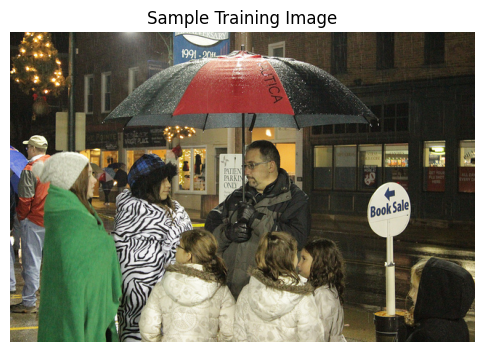

In [ ]:
# ===============================
# DATA VALIDATION + SAMPLE DISPLAY
# ===============================

import os
import json
import matplotlib.pyplot as plt
from PIL import Image

# Paths
train_img_dir = os.path.join(DATA_ROOT, "train-300/data")
train_labels_path = os.path.join(DATA_ROOT, "train-300/labels.json")

val_img_dir = os.path.join(DATA_ROOT, "validation-300/data")
val_labels_path = os.path.join(DATA_ROOT, "validation-300/labels.json")

test_img_dir = os.path.join(DATA_ROOT, "test-30")

# Verify directories exist
print("Train images:", os.path.exists(train_img_dir))
print("Validation images:", os.path.exists(val_img_dir))
print("Test images:", os.path.exists(test_img_dir))

# Load annotations
with open(train_labels_path) as f:
    train_labels = json.load(f)

with open(val_labels_path) as f:
    val_labels = json.load(f)

# Print dataset statistics
print("\n=== DATASET STATISTICS ===")
print("Training images:", len(os.listdir(train_img_dir)))
print("Training annotations:", len(train_labels["annotations"]))
print("Validation images:", len(os.listdir(val_img_dir)))
print("Validation annotations:", len(val_labels["annotations"]))
print("Number of categories:", len(train_labels["categories"]))

# Show one random training image
sample_image = os.listdir(train_img_dir)[0]
img_path = os.path.join(train_img_dir, sample_image)

img = Image.open(img_path)
plt.figure(figsize=(6,6))
plt.title("Sample Training Image")
plt.imshow(img)
plt.axis("off")
plt.show()

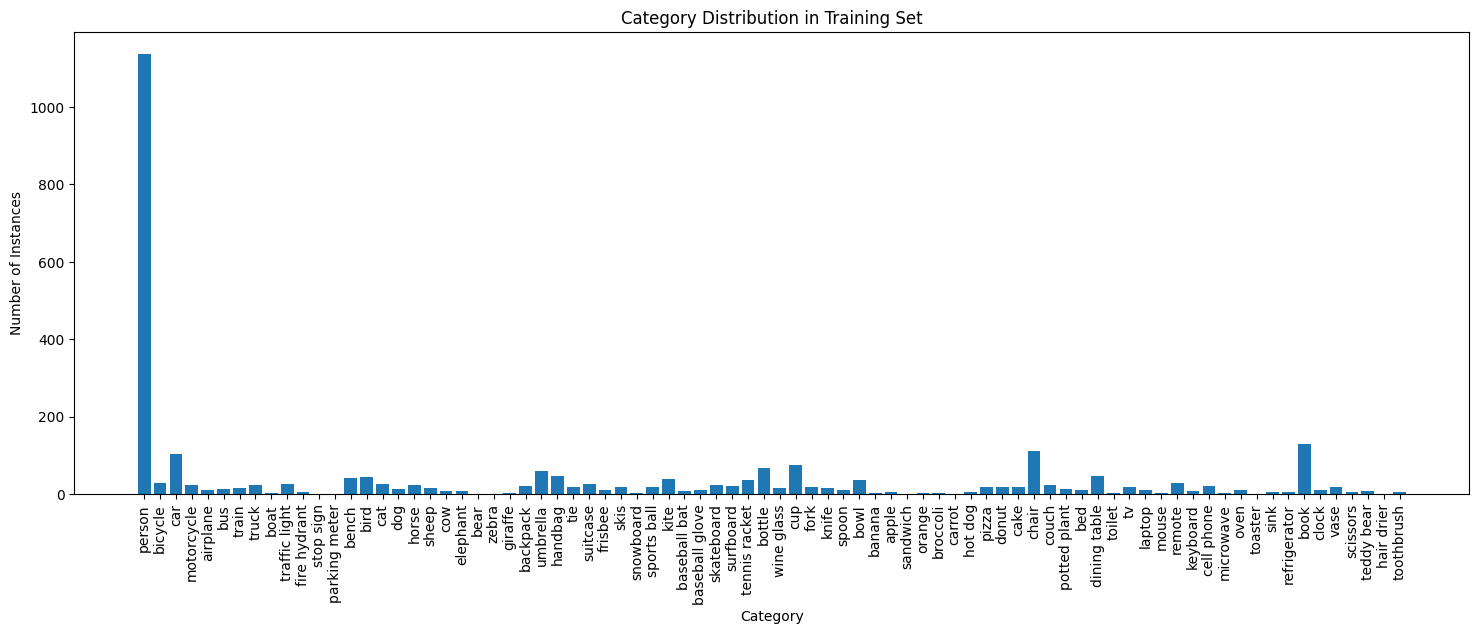

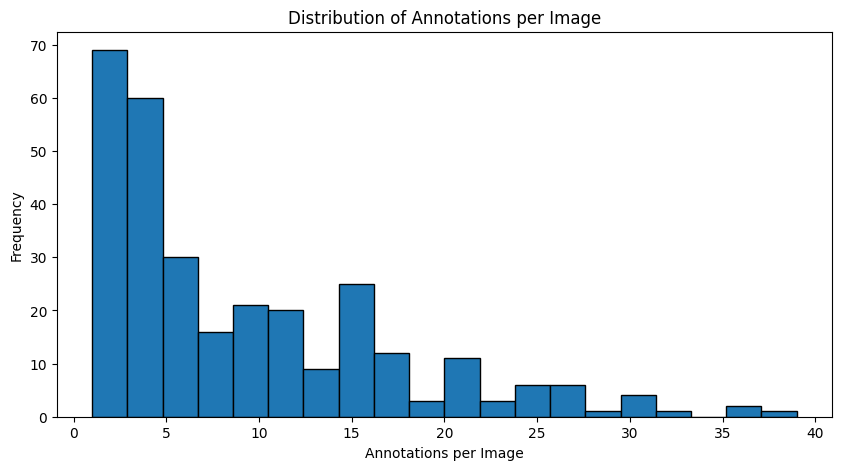

In [ ]:
# ===============================
# EXPLORATORY DATA ANALYSIS (EDA)
# ===============================

import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import random
import cv2

# Extract category information
categories = {cat['id']: cat['name'] for cat in train_labels['categories']}

# Count category instances
cat_counter = Counter([ann['category_id'] for ann in train_labels['annotations']])

# --- Plot Category Distribution ---
plt.figure(figsize=(18, 6))
plt.bar(categories.values(), [cat_counter[cat_id] for cat_id in categories.keys()])
plt.xticks(rotation=90)
plt.title("Category Distribution in Training Set")
plt.xlabel("Category")
plt.ylabel("Number of Instances")
plt.show()


# --- Plot Annotation Count per Image ---
ann_per_img = Counter([ann['image_id'] for ann in train_labels['annotations']])

plt.figure(figsize=(10, 5))
plt.hist(list(ann_per_img.values()), bins=20, edgecolor='black')
plt.title("Distribution of Annotations per Image")
plt.xlabel("Annotations per Image")
plt.ylabel("Frequency")
plt.show()


Displaying 3 random annotated training examples with masks:


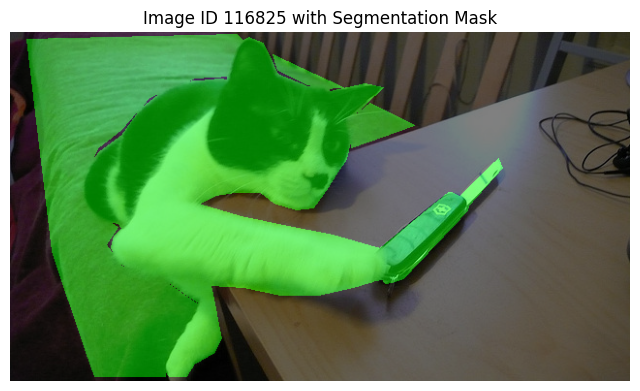

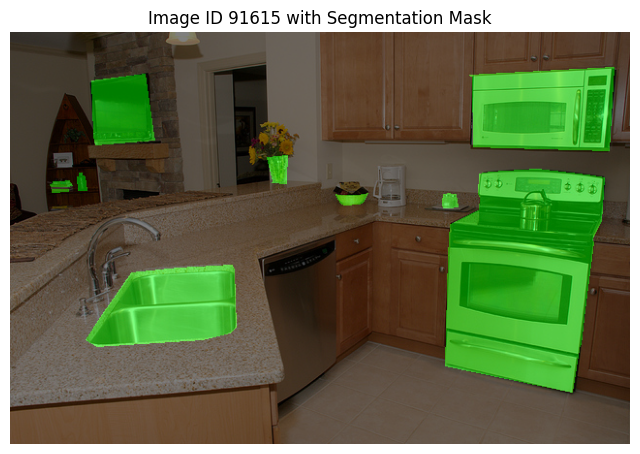

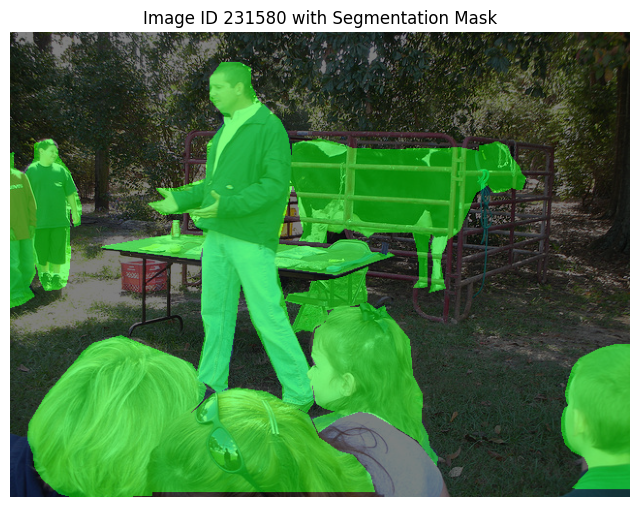

In [ ]:
# ===============================
# VISUALIZE IMAGE + SEGMENTATION MASK
# ===============================

def get_image_info(image_id, labels):
    for img_info in labels['images']:
        if img_info['id'] == image_id:
            return img_info
    return None

def plot_img_with_masks(image_id, labels, img_dir):
    image_info = get_image_info(image_id, labels)
    img_path = os.path.join(img_dir, image_info['file_name'])

    img = np.array(Image.open(img_path))
    mask_canvas = np.zeros_like(img, dtype=np.uint8)

    anns = [ann for ann in labels['annotations'] if ann['image_id'] == image_id]

    for ann in anns:
        if 'segmentation' in ann and isinstance(ann['segmentation'], list):
            for seg in ann['segmentation']:
                poly = np.array(seg).reshape((-1, 2)).astype(np.int32)
                cv2.fillPoly(mask_canvas, [poly], (0, 255, 0)) # green overlay

    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.imshow(mask_canvas, alpha=0.5) # overlay
    plt.title(f"Image ID {image_id} with Segmentation Mask")
    plt.axis("off")
    plt.show()


# Display 3 sample images with masks
print("\nDisplaying 3 random annotated training examples with masks:")
sample_ids = random.sample(list(ann_per_img.keys()), 3)
for img_id in sample_ids:
    plot_img_with_masks(img_id, train_labels, train_img_dir)

In [ ]:
# ============================================
# CONVERT COCO FORMAT TO YOLOv8-SEG FORMAT
# ============================================

import json
import os
import numpy as np
from tqdm import tqdm

def convert_annotations(labels, img_dir, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    image_lookup = {img['id']: img for img in labels["images"]}

    for ann in tqdm(labels['annotations'], desc="Converting annotations"):
        img_info = image_lookup[ann["image_id"]]
        img_file = img_info['file_name']

        # Source & target label paths
        label_path = os.path.join(output_dir, img_file.replace('.jpg', '.txt').replace('.png', '.txt'))

        img_width = img_info['width']
        img_height = img_info['height']

        # Prepare segmentation polygons
        seg_data = []
        if 'segmentation' in ann and isinstance(ann['segmentation'], list):
            for poly in ann['segmentation']:
                xy = np.array(poly).reshape(-1, 2)
                xy[:, 0] = xy[:, 0] / img_width
                xy[:, 1] = xy[:, 1] / img_height
                seg_data.extend(xy.flatten().tolist())

        # Ensure segmentation exists
        if len(seg_data) < 6:  # Not enough points for a polygon
            continue

        # Convert COCO class id → YOLO class index (start at 0)
        class_id = ann['category_id'] - 1

        # Write YOLO label
        with open(label_path, "a") as f:
            f.write(f"{class_id} " + " ".join(map(str, seg_data)) + "\n")


# ==== RUN CONVERSION FOR TRAIN + VAL ====
train_label_out = os.path.join(DATA_ROOT, "train-300/labels")
val_label_out = os.path.join(DATA_ROOT, "validation-300/labels")

convert_annotations(train_labels, train_img_dir, train_label_out)
convert_annotations(val_labels, val_img_dir, val_label_out)

print("Annotation conversion complete!")

Converting annotations: 100%|██████████| 2686/2686 [00:13<00:00, 197.82it/s]

Annotation conversion complete!


In [ ]:
# =========================================
# FIX LABEL LOCATION + YAML + REMOVE CACHE
# =========================================

import shutil

# Correct new paths (your confirmed structure)
train_img_dir = os.path.join(DATA_ROOT, "train-300/data")
val_img_dir = os.path.join(DATA_ROOT, "validation-300/data")

train_label_out = os.path.join(DATA_ROOT, "train-300/labels")
val_label_out = os.path.join(DATA_ROOT, "validation-300/labels")

# Move TXT labels next to images for YOLO compatibility
def move_labels(label_dir, img_dir):
    if os.path.exists(label_dir):
        for f in os.listdir(label_dir):
            if f.endswith(".txt"):
                shutil.move(os.path.join(label_dir, f),
                            os.path.join(img_dir, f))
        print(f"Moved labels into {img_dir}")
    else:
        print(f"Label directory not found: {label_dir}")

move_labels(train_label_out, train_img_dir)
move_labels(val_label_out, val_img_dir)

# Fix YOLO dataset YAML (remove /images from earlier mistake)
dataset_yaml = f"""
path: {DATA_ROOT}
train: train-300/data
val: validation-300/data

names: [
"""

for i in range(len(train_labels["categories"])):
    dataset_yaml += f"'{train_labels['categories'][i]['name']}', "

dataset_yaml = dataset_yaml.rstrip(", ") + "]"

yaml_path = "/content/coco_seg_fixed.yaml"
with open(yaml_path, "w") as f:
    f.write(dataset_yaml)

print("YAML file updated:", yaml_path)

# Remove any cached YOLO scan results (IMPORTANT)
!rm -f {train_img_dir}/data.cache
!rm -f {val_img_dir}/data.cache
print("Removed old YOLO caches")

Moved labels into /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/train-300/data
Moved labels into /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/validation-300/data
YAML file updated: /content/coco_seg_fixed.yaml
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `rm -f /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/train-300/data/data.cache'
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `rm -f /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/validation-300/data/data.cache'
Removed old YOLO caches


In [ ]:
# ==========================
# TRAIN YOLOv8-SEG MODEL
# ==========================

from ultralytics import YOLO

model = YOLO("yolov8s-seg.pt")

results = model.train(
    data=yaml_path,
    epochs=30,
    imgsz=640,
    batch=4,
    workers=2,
    patience=10,
    project="YOLO_COCO_SEG",
    name="exp_fixed",
    exist_ok=True,
)

print("Training complete!")

Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/coco_seg_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp_fixed, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, p

In [ ]:
# ============================================
# RUN INFERENCE ON TEST IMAGES
# ============================================

from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
from PIL import Image

# Load best trained model
best_model_path = "/content/YOLO_COCO_SEG/exp_fixed/weights/best.pt"
model = YOLO(best_model_path)

# Output folder for test results
output_folder = "/content/Yolo_Test_Results"
os.makedirs(output_folder, exist_ok=True)

# Run prediction on test set
test_results = model.predict(
    source=test_img_dir,  # test-30 images
    save=True,
    save_txt=True,
    save_conf=True,
    project=output_folder,
    name="preds",
    imgsz=640,
)

print("\nInference complete! Results saved to:", output_folder)


image 1/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/test-30/000000013177.jpg: 448x640 1 person, 4 bicycles, 3 motorcycles, 63.9ms
image 2/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/test-30/000000013291.jpg: 448x640 6 persons, 4 kites, 16.4ms
image 3/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/test-30/000000050380.jpg: 448x640 4 persons, 1 sheep, 1 toilet, 1 laptop, 16.5ms
image 4/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/test-30/000000066771.jpg: 480x640 2 persons, 3 bananas, 1 broccoli, 1 tv, 1 keyboard, 1 scissors, 61.7ms
image 5/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/test-30/000000079969.jpg: 640x448 8 persons, 1 bird, 63.1ms
image 6/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/test-30/000000117525.jpg: 640x640 1 person, 1 dog, 21.9ms
image 7/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Fil


CSV Columns: ['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
Detected loss columns: ['train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss']


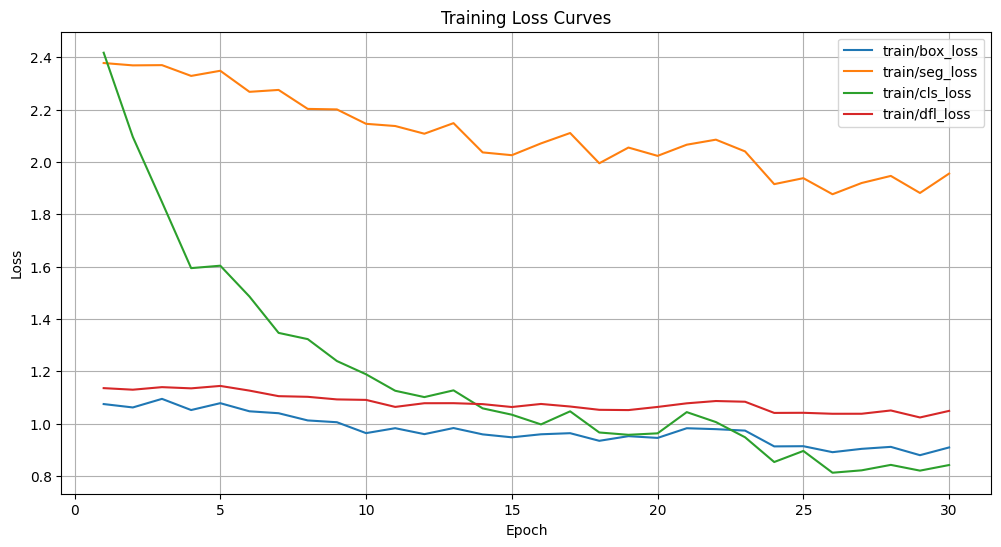

In [ ]:
# =====================================
# UNIVERSAL TRAINING LOSS PLOTS
# =====================================
import pandas as pd
import matplotlib.pyplot as plt

results_csv = "/content/YOLO_COCO_SEG/exp_fixed/results.csv"
df = pd.read_csv(results_csv)

# Print columns so we know what we're working with
print("\nCSV Columns:", list(df.columns))

# Auto-detect loss column names
loss_cols = [c for c in df.columns if "loss" in c and "val" not in c]
print("Detected loss columns:", loss_cols)

plt.figure(figsize=(12, 6))
for col in loss_cols:
    plt.plot(df["epoch"], df[col], label=col)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

Detected mAP columns: ['metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)']


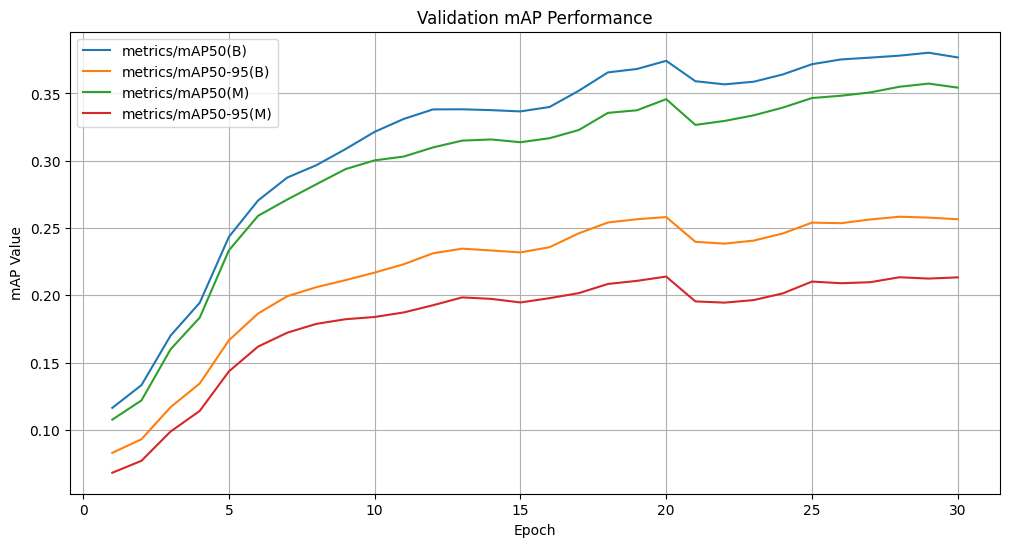

In [ ]:
# =====================================
# UNIVERSAL mAP CURVE PLOTS
# =====================================
map_cols = [c for c in df.columns if "mAP" in c]
print("Detected mAP columns:", map_cols)

plt.figure(figsize=(12, 6))
for col in map_cols:
    plt.plot(df["epoch"], df[col], label=col)

plt.xlabel("Epoch")
plt.ylabel("mAP Value")
plt.title("Validation mAP Performance")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# =====================================
# PRINT FINAL EVALUATION METRICS
# =====================================
last = df.iloc[-1]

print("\n=== Final Validation Metrics ===")
for col in map_cols:
    print(f"{col}: {last[col]:.3f}")


=== Final Validation Metrics ===
metrics/mAP50(B): 0.377
metrics/mAP50-95(B): 0.257
metrics/mAP50(M): 0.354
metrics/mAP50-95(M): 0.213


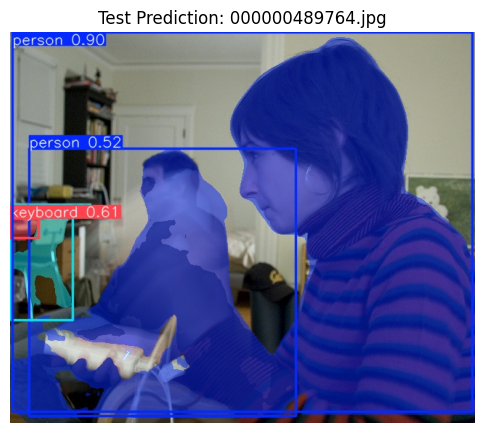

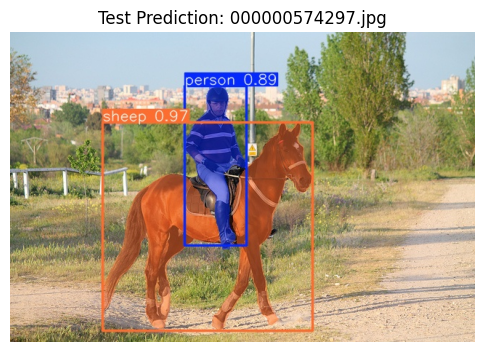

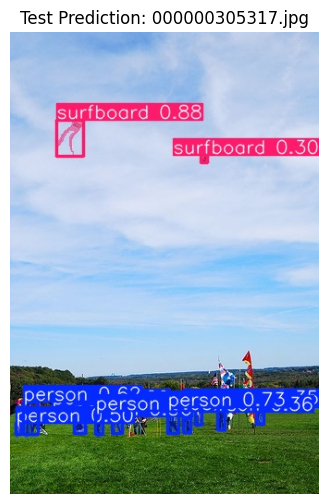

In [ ]:
# ============================================
# DISPLAY 3 RANDOM TEST PREDICTIONS
# ============================================

import random

pred_images_dir = os.path.join(output_folder, "preds")
pred_files = [f for f in os.listdir(pred_images_dir) if f.endswith(".jpg") or f.endswith(".png")]

# Select 3 random predictions
sample_preds = random.sample(pred_files, 3)

for img_file in sample_preds:
    img_path = os.path.join(pred_images_dir, img_file)

    img = Image.open(img_path)
    plt.figure(figsize=(6,6))
    plt.title(f"Test Prediction: {img_file}")
    plt.imshow(img)
    plt.axis("off")
    plt.show()


In [ ]:
# =====================================
# TRAIN 2nd MODEL: YOLOv8m-seg
# =====================================

from ultralytics import YOLO

model_m = YOLO("yolov8m-seg.pt")

results_m = model_m.train(
    data=yaml_path,
    epochs=40,
    imgsz=640,
    batch=4,       # Medium model requires smaller batch
    workers=2,
    patience=12,
    project="YOLO_COCO_SEG",
    name="exp_medium",
    exist_ok=True
)

print("Training (Medium model) complete!")

Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/coco_seg_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp_medium, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=12, perspective=0.0, plots=True, 

In [ ]:
# =====================================
# FULL EVALUATION: YOLOv8-m-seg Model
# =====================================
import pandas as pd
import matplotlib.pyplot as plt
import os
from ultralytics import YOLO
from PIL import Image
import random

# Load training results CSV
results_csv_m = "/content/YOLO_COCO_SEG/exp_medium/results.csv"
df_m = pd.read_csv(results_csv_m)

print("CSV Columns Detected:\n", list(df_m.columns))

CSV Columns Detected:
 ['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)', 'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)', 'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


Loss Columns: ['train/box_loss', 'train/seg_loss', 'train/cls_loss', 'train/dfl_loss']


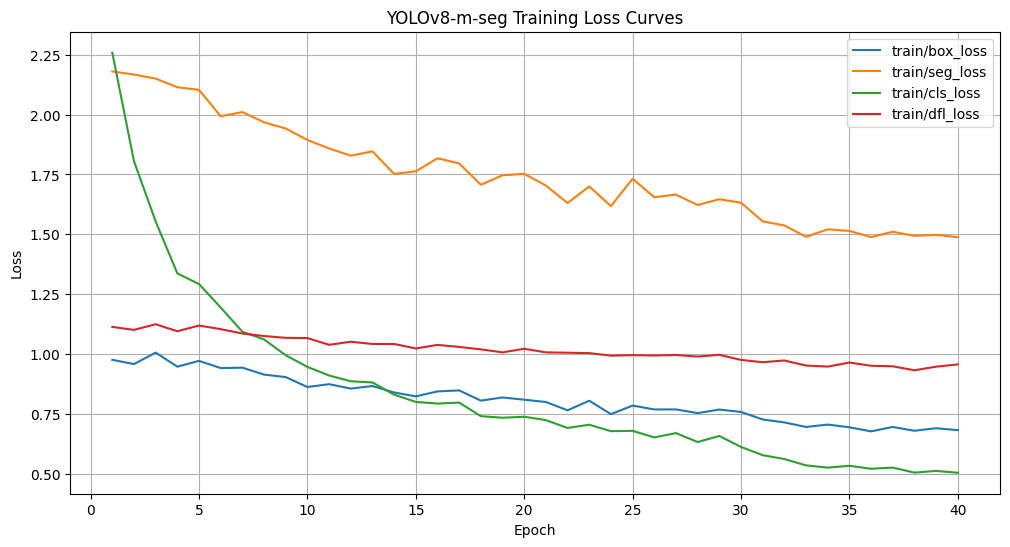

In [ ]:
# -------------------------------------
# Plot Loss Curves
# -------------------------------------
loss_cols_m = [c for c in df_m.columns if "loss" in c and "val" not in c]
print("Loss Columns:", loss_cols_m)

plt.figure(figsize=(12, 6))
for col in loss_cols_m:
    plt.plot(df_m["epoch"], df_m[col], label=col)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLOv8-m-seg Training Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

mAP Columns: ['metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)']


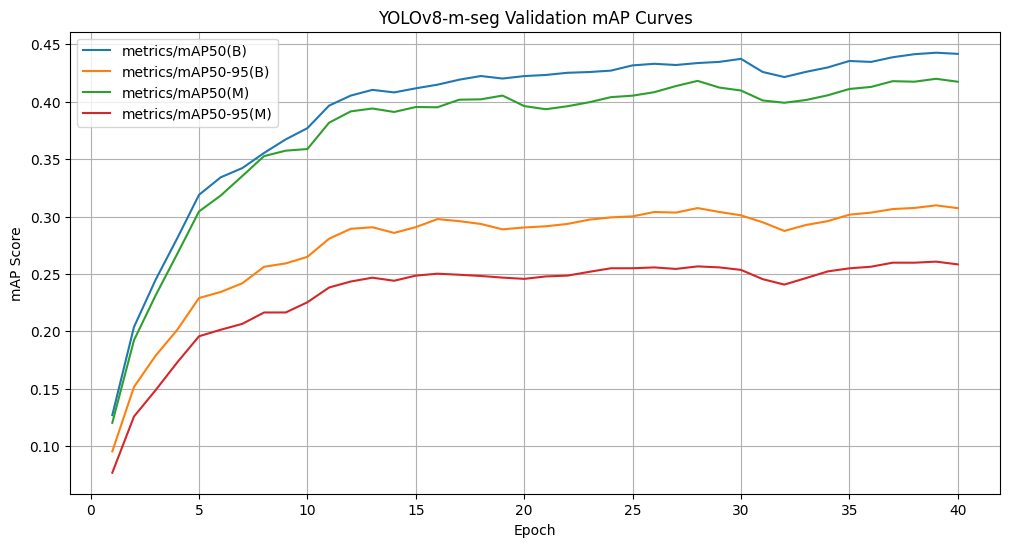

In [ ]:
# -------------------------------------
# Plot mAP Metric Curves
# -------------------------------------
map_cols_m = [c for c in df_m.columns if "mAP" in c]
print("mAP Columns:", map_cols_m)

plt.figure(figsize=(12, 6))
for col in map_cols_m:
    plt.plot(df_m["epoch"], df_m[col], label=col)
plt.xlabel("Epoch")
plt.ylabel("mAP Score")
plt.title("YOLOv8-m-seg Validation mAP Curves")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# -------------------------------------
# Display final mAP performance values
# -------------------------------------
last_m = df_m.iloc[-1]

print("\n=== Final Validation Metrics (YOLOv8-m-seg) ===")
for col in map_cols_m:
    print(f"{col}: {last_m[col]:.3f}")


=== Final Validation Metrics (YOLOv8-m-seg) ===
metrics/mAP50(B): 0.442
metrics/mAP50-95(B): 0.307
metrics/mAP50(M): 0.417
metrics/mAP50-95(M): 0.258


In [ ]:
# -------------------------------------
# Run inference on test images
# -------------------------------------
medium_model_path = "/content/YOLO_COCO_SEG/exp_medium/weights/best.pt"
model_medium = YOLO(medium_model_path)

test_output_dir = "/content/Yolo_Test_Results_medium"
os.makedirs(test_output_dir, exist_ok=True)

model_medium.predict(
    source=test_img_dir,
    save=True,
    name="preds_medium",
    project=test_output_dir,
    imgsz=640,
)

print("\nInference complete! Results saved to:", test_output_dir)


image 1/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/test-30/000000013177.jpg: 448x640 1 person, 2 bicycles, 86.2ms
image 2/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/test-30/000000013291.jpg: 448x640 5 persons, 4 kites, 33.7ms
image 3/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/test-30/000000050380.jpg: 448x640 3 persons, 1 sheep, 1 toilet, 32.8ms
image 4/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/test-30/000000066771.jpg: 480x640 2 persons, 4 bananas, 1 orange, 2 broccolis, 1 tv, 1 keyboard, 1 scissors, 82.2ms
image 5/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/test-30/000000079969.jpg: 640x448 12 persons, 82.4ms
image 6/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files)/test-30/000000117525.jpg: 640x640 1 person, 1 traffic light, 1 horse, 43.1ms
image 7/30 /content/drive/MyDrive/RMDS_Segmentation_Assignment (Unzipped Files


Showing 3 sample predictions:


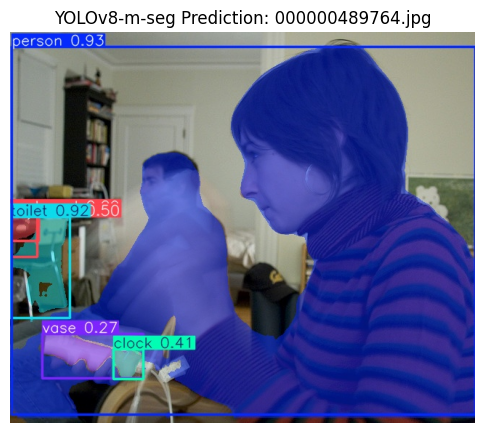

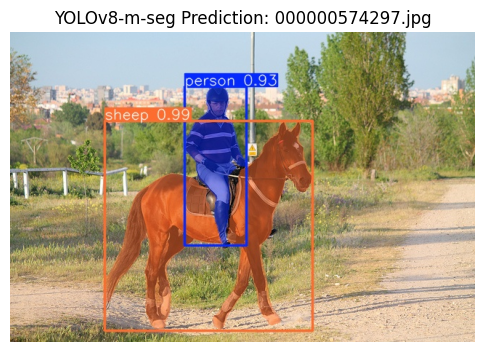

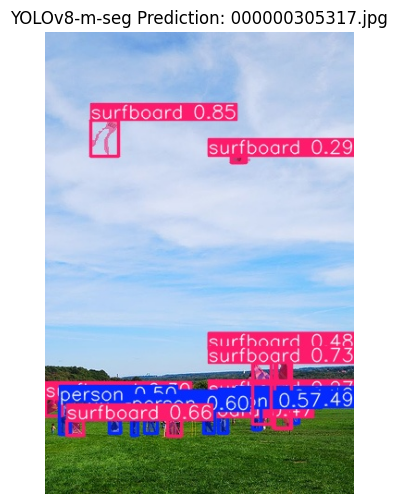

In [ ]:
# -------------------------------------
# Display 3 prediction examples
# -------------------------------------
pred_medium_dir = os.path.join(test_output_dir, "preds_medium")
pred_files = [f for f in os.listdir(pred_medium_dir) if f.endswith(".jpg")]

sample_preds_m = random.sample(pred_files, 3)
print("\nShowing 3 sample predictions:")

for img_file in sample_preds_m:
    img_path = os.path.join(pred_medium_dir, img_file)
    img = Image.open(img_path)
    plt.figure(figsize=(6,6))
    plt.title(f"YOLOv8-m-seg Prediction: {img_file}")
    plt.imshow(img)
    plt.axis("off")
    plt.show()